In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sbn
import numpy as np 

import torch

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score, silhouette_samples
import umap
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from amlvae.models.VAE import VAE 
from amlvae.train.Trainer import Trainer

from amlvae.data.ExprProcessor import ExprProcessor
from amlvae.data.ClinProcessor import ClinProcessor

from sklearn.model_selection import KFold

from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split

import umap 
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sksurv.nonparametric import kaplan_meier_estimator

# auto reimport 
%load_ext autoreload
%autoreload 2

In [2]:
model = torch.load('./data/amlmds_vae_model.pt', map_location=torch.device('cpu'))

/tmp/ipykernel_27728/4236188255.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('./data/amlmds_vae_model.pt', map_location=torch.device('cpu'))


In [3]:
aml_clin = pd.read_csv('../data/beataml_clinical_for_inputs.csv')
priorMDS_ids = aml_clin[lambda x: x.priorMDS == 'y'].gdc_id.unique()
drug = pd.read_csv('../data/beataml_probit_curve_fits_v4_distr.txt', sep='\t').merge(aml_clin[['gdc_id', 'labId']], left_on='lab_id', right_on='labId', how='inner') 

zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')

In [4]:
drug = drug[['gdc_id', 'inhibitor', 'auc']]
drug = drug[lambda x: x.inhibitor == 'Idelalisib']
drug.shape

(374, 3)

In [5]:
zdf = zdf.merge(drug, left_on='id', right_on='gdc_id', how='left')

In [6]:
zdf = zdf[lambda x: x['auc'].notna()]

z_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values 
y_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)]['auc'].values 

z_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values
y_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)]['auc'].values 

yt = np.quantile(y_train, 0.5) 

y_train = y_train < yt
y_test = y_test < yt 

mod = RandomForestClassifier(n_estimators=500, max_depth=5)

scores = cross_val_score(mod, z_train, y_train, cv=5, scoring='roc_auc')
print(f'Cross-validated ROC AUC: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')

mod.fit(z_train, y_train)
y_pred = mod.predict_proba(z_test)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score
roc_auc = roc_auc_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred > 0.5)
print(f'Test ROC AUC: {roc_auc:.3f}')   
print(f'Test accuracy: {acc:.3f}')

Cross-validated ROC AUC: 0.659 +/- 0.070
Test ROC AUC: 0.874
Test accuracy: 0.758


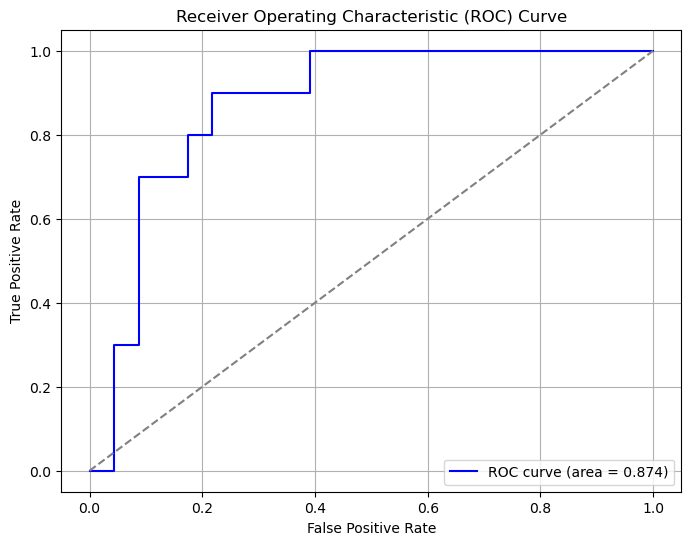

In [7]:
# auroc curve 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = {:.3f})'.format(roc_auc), color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

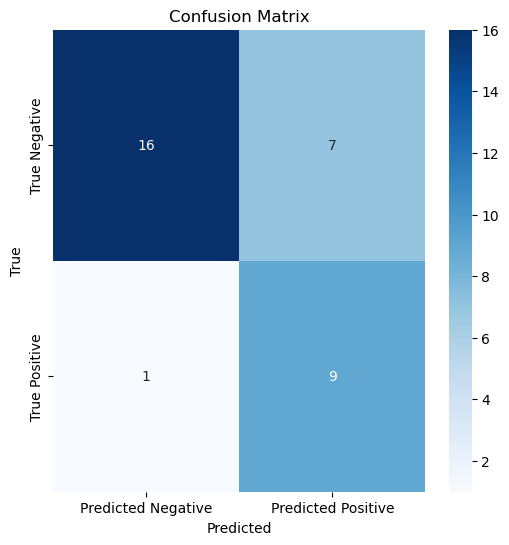

In [8]:
# confusion 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred > 0.5)
import seaborn as sns
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['True Negative', 'True Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

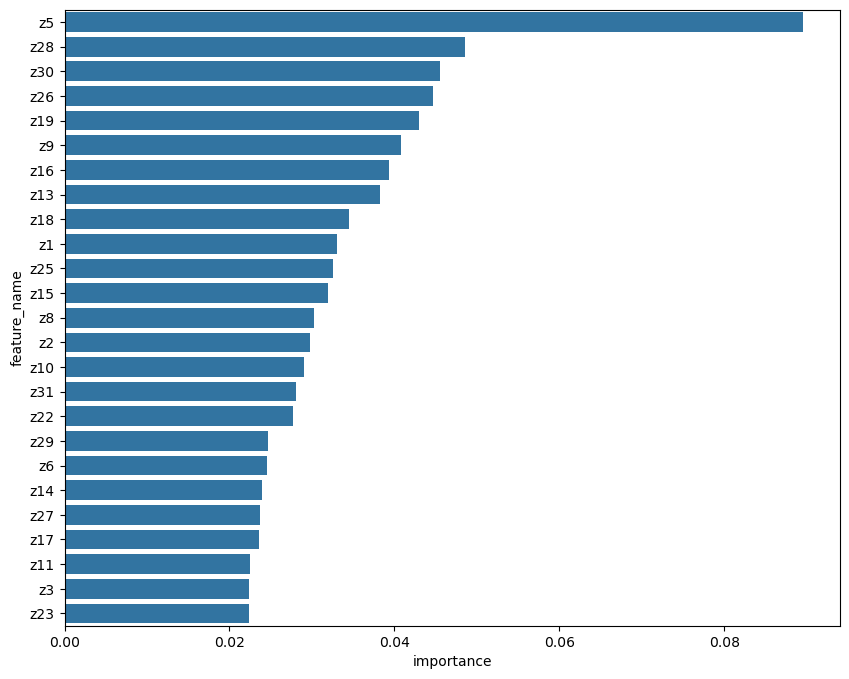

In [9]:
imp_df = pd.DataFrame({'importance':mod.feature_importances_, 'feature_name' : [f'z{i}' for i in range(model.latent_dim)]}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sbn.barplot(data=imp_df.head(25), y='feature_name', x='importance') 
plt.show() 

In [10]:
zdf[imp_df.feature_name.values[0:3]].corr()

,z5,z28,z30
z5,1.000000,-0.064500,0.067803
z28,-0.064500,1.000000,-0.107613
z30,0.067803,-0.107613,1.000000


In [11]:
# what does z31 look like in MDS patients? (do distributions mds/aml overlap or separate?)
# run this analysis with azacitadine
# " ven + aza (relatively few patients) and other ven combinations.
# joint expr + mut vae embeddings (select mut features baseed on aml/mds frequency similarity.)
# celltype scoring (beataml) compared to z31 
# what genes are predictive of z31? what mut/sv might drive z31 signature --> corr. with z31 mut/sv  

Spearman correlation between z11 and z27: 0.324, p-value: 2.094e-10


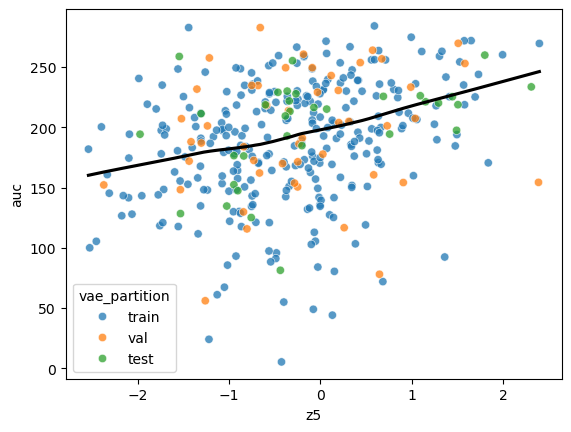

Spearman correlation between z11 and z27: -0.207, p-value: 6.696e-05


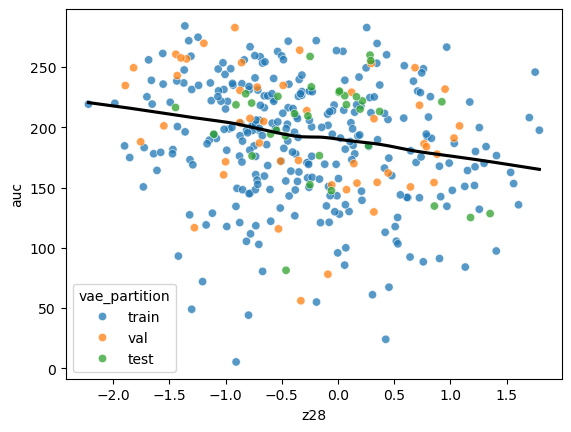

Spearman correlation between z11 and z27: 0.160, p-value: 2.072e-03


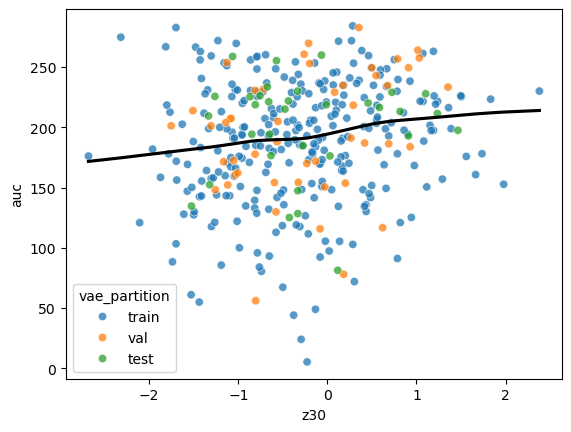

In [12]:
for f1 in imp_df.feature_name.values[:3]:

    corr = spearmanr(zdf[f1], zdf.auc)
    print(f'Spearman correlation between z11 and z27: {corr.statistic:.3f}, p-value: {corr.pvalue:.3e}')

    plt.figure() 
    sbn.scatterplot(data=zdf, x=f1, y='auc', hue='vae_partition', alpha=0.75)
    sbn.regplot(data=zdf, x=f1, y='auc', ci=True, lowess=True, scatter=False, color='black')
    plt.show() 

# compare venetoclax-correlated latent embeddings to monocyte-like score

In [13]:
zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')
zdf = zdf.merge(aml_clin[['gdc_id', 'labId', 'overallSurvival']], left_on='id', right_on='gdc_id', how='inner')
celltype = pd.read_excel('../data/beataml_wv_1to4_vg_cts.xlsx').merge(aml_clin[['gdc_id', 'labId']], on='labId', how='inner')
celltype = celltype[['gdc_id', 'GMP-like', 'HSC-like', 'Monocyte-like', 'Progenitor-like', 'Promono-like', 'cDC-like']]
zdf = zdf.merge(celltype, on='gdc_id', how='left')

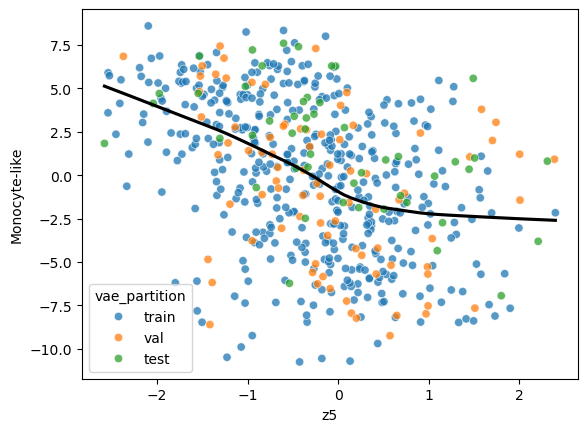

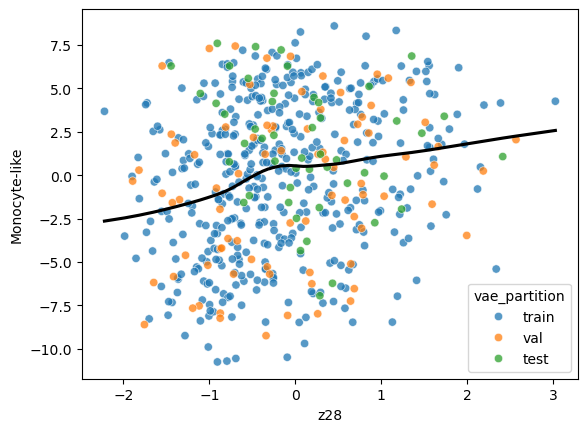

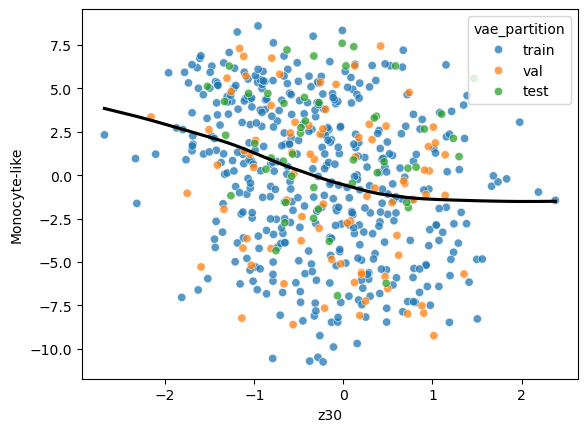

In [14]:
for f1 in imp_df.feature_name.values[:3]:

    plt.figure() 
    sbn.scatterplot(data=zdf, x=f1, y='Monocyte-like', hue='vae_partition', alpha=0.75)
    sbn.regplot(data=zdf, x=f1, y='Monocyte-like', ci=True, lowess=True, scatter=False, color='black')
    plt.show() 

Monocyte-like low threshold: -2.5261532262061004, high threshold: 2.3076309190271327


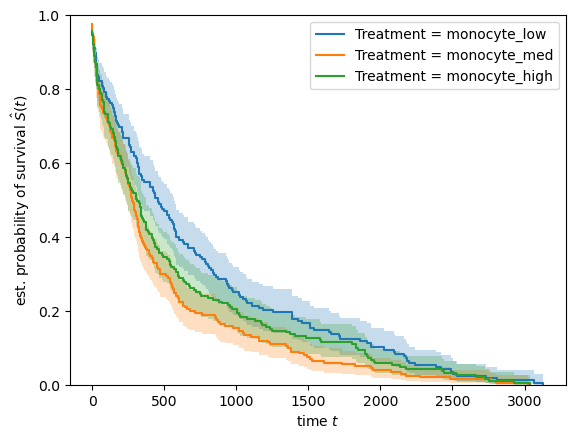

In [15]:
t_low =  np.quantile(zdf['Monocyte-like'], 0.3)
t_high = np.quantile(zdf['Monocyte-like'], 0.66)

print(f"Monocyte-like low threshold: {t_low}, high threshold: {t_high}")

for treatment_type in ('monocyte_low', 'monocyte_med', 'monocyte_high'):

    if treatment_type == 'monocyte_low':
        mask_treat = zdf['Monocyte-like'] < t_low
    elif treatment_type == 'monocyte_med':
        mask_treat = (zdf['Monocyte-like'] >= t_low) & (zdf['Monocyte-like'] < t_high)
    elif treatment_type == 'monocyte_high':
        mask_treat = zdf['Monocyte-like'] >= t_high
    else:
        raise ValueError(f"Unknown treatment type: {treatment_type}")

    time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
        event = [True] * mask_treat.sum(), 
        time_exit = zdf["overallSurvival"][mask_treat], 
        conf_type = "log-log")

    plt.step(time_treatment, survival_prob_treatment, where="post", label=f"Treatment = {treatment_type}")
    plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.show() 

In [16]:
z_all = zdf[zdf.columns[:model.latent_dim]].values
pred_resp = mod.predict_proba(z_all)[:, 1] # high values indicate sensitive to response 

zdf = zdf.assign(pred_resp=pred_resp) 

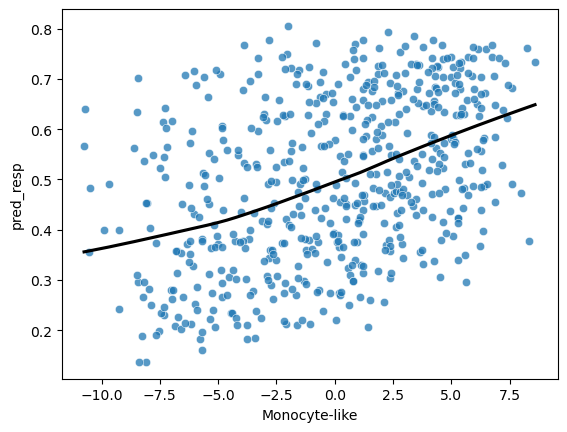

In [17]:
plt.figure() 
sbn.scatterplot(data=zdf, x='Monocyte-like', y='pred_resp', alpha=0.75)
sbn.regplot(data=zdf, x='Monocyte-like', y='pred_resp', ci=True, lowess=True, scatter=False, color='black')
plt.show() 

# for the venetoclax-correlated latent dims, do any mutations correlate ?

In [18]:
zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')
zdf = zdf.assign(aml = [('-' in x) for x in zdf.id])

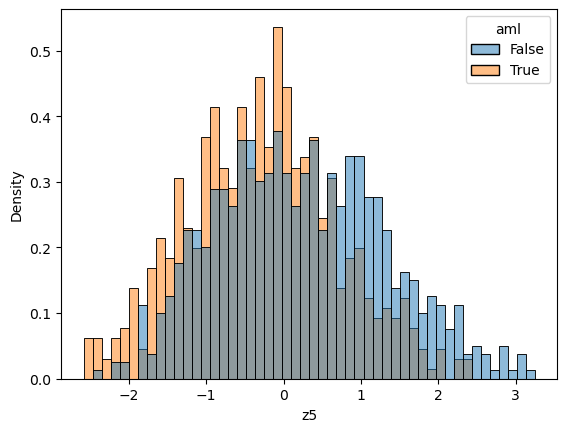

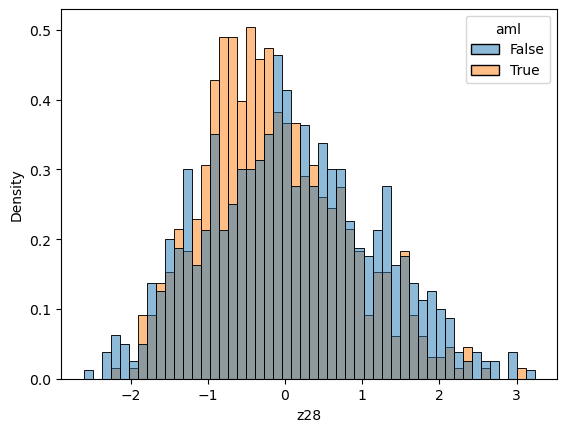

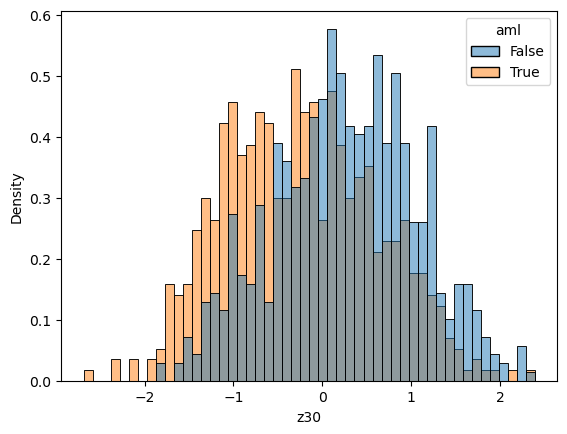

In [19]:
for f1 in imp_df.feature_name.values[:3]:

    plt.figure() 
    sbn.histplot(data=zdf, x=f1, hue='aml', stat='density', common_norm=False, bins=50)
    plt.show() 

# predicted ven response compared to MDS survival 

In [20]:
mds_clin = pd.read_excel('/home/teddy/local/AMLVAE/data/805_data_20250107.xlsx')
zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')
zdf = zdf.merge(mds_clin, left_on='id', right_on='MLL ID', how='inner')

In [21]:
z_all = zdf[zdf.columns[:model.latent_dim]].values
pred_resp = mod.predict_proba(z_all)[:, 1] # high values indicate sensitive to response 

zdf = zdf.assign(pred_resp=pred_resp) 
zdf = zdf.assign(log_survival=np.log(zdf['Overall survival (days)'] + 1)) # add 1 to avoid log(0)

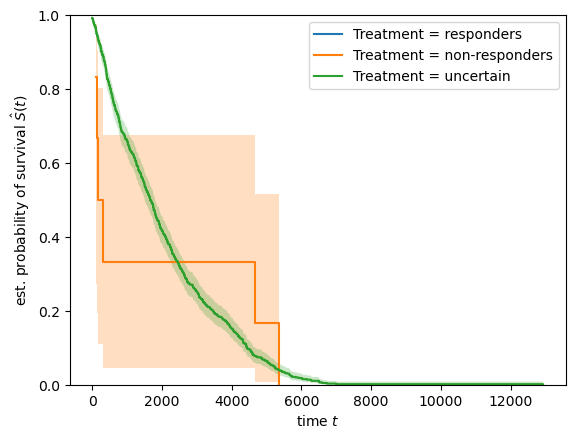

In [22]:
t_low = 0.33
t_high = 0.66

for treatment_type in ('responders', 'non-responders', 'uncertain'):

    if treatment_type == 'responders':
        mask_treat = zdf["pred_resp"] > t_high
    elif treatment_type == 'non-responders':
        mask_treat = zdf["pred_resp"] < t_low
    else:   
        mask_treat = zdf["pred_resp"].between(t_low, t_high)

    time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
        event = [True] * mask_treat.sum(), 
        time_exit = zdf["Overall survival (days)"][mask_treat], 
        conf_type = "log-log")

    plt.step(time_treatment, survival_prob_treatment, where="post", label=f"Treatment = {treatment_type}")
    plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")
plt.show() 

# mutation and predicted response

/tmp/ipykernel_27728/2710834076.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')] = mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STA

Cross-validated R2: 0.592 +/- 0.064


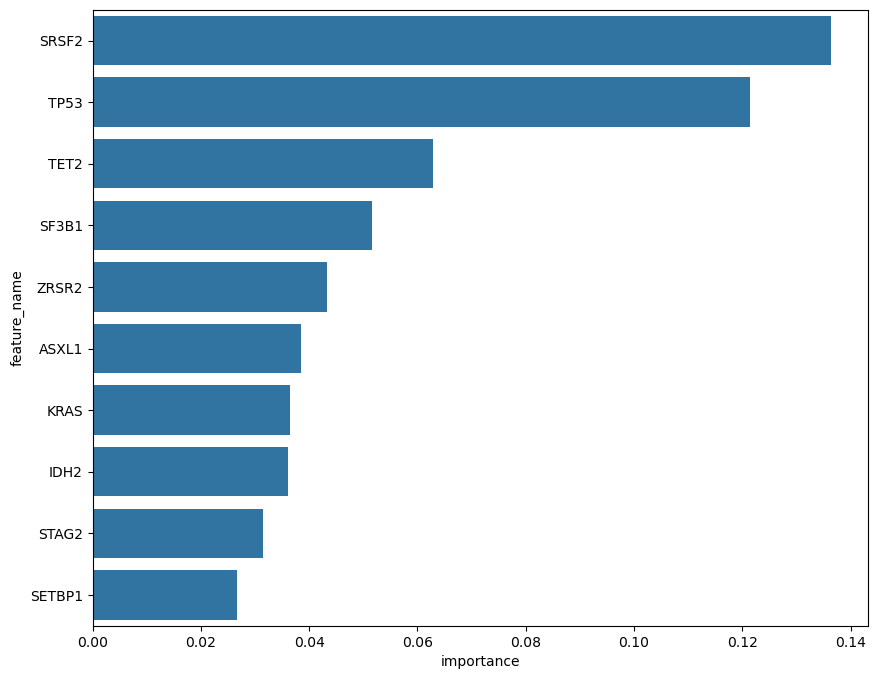

In [23]:
mds_clin = pd.read_excel('/home/teddy/local/AMLVAE/data/805_data_20250107.xlsx')
zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')
zdf = zdf.merge(mds_clin, left_on='id', right_on='MLL ID', how='inner')
mut_zdf = zdf[[f'z{i}' for i in range(model.latent_dim)] + 'ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')]
mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')] = mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')].values == 'POSITIVE'

y = mod.predict(mut_zdf[[f'z{i}' for i in range(model.latent_dim)]].values) 
x = mut_zdf[mut_zdf.columns[model.latent_dim:]].values

mod2 = RandomForestClassifier(n_estimators=500, max_depth=5)
scores = cross_val_score(mod2, x, y, cv=5, scoring='roc_auc')
print(f'Cross-validated R2: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')
mod2.fit(x, y)

imp_df_muts = pd.DataFrame({'importance':mod2.feature_importances_, 'feature_name' : mut_zdf.columns[model.latent_dim:]}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
sbn.barplot(data=imp_df_muts.head(10), y='feature_name', x='importance')
plt.show()

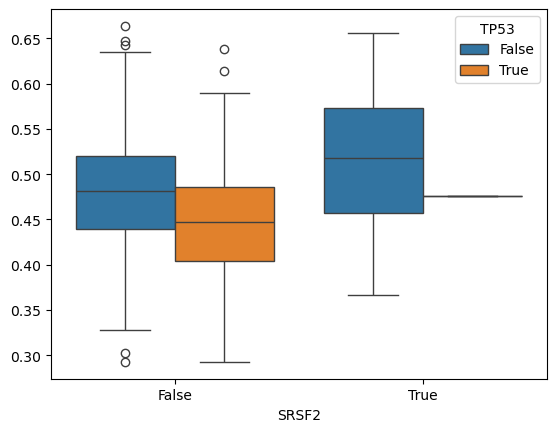

In [26]:
plt.figure() 
sbn.boxplot(data=mut_zdf, x='SRSF2', hue='TP53', y=mod.predict_proba(mut_zdf[[f'z{i}' for i in range(model.latent_dim)]].values)[:, 1] )
plt.show() 

# DO any MDS mutations correlate with the venetoclax-correlated latent dims? 

In [23]:
mds_clin = pd.read_excel('/home/teddy/local/AMLVAE/data/805_data_20250107.xlsx')
zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')
zdf = zdf.merge(mds_clin, left_on='id', right_on='MLL ID', how='inner')

In [24]:
mut_zdf = zdf[imp_df.feature_name.values[:3].tolist() + 'ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')]
mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')] = mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')].values == 'POSITIVE'

/tmp/ipykernel_19510/2007224664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STAG2,SUZ12,TET2,TP53,U2AF1,U2AF2,UBA1,WT1,ZEB2,ZRSR2'.split(',')] = mut_zdf['ASXL1,ASXL2,ATRX,BCOR,BCORL1,BRAF,CALR,CBL,CEBPA,CSF3R,CSNK1A1,CUX1,DDX41,DNMT3A,ETNK1,ETV6,EZH2,FBXW7,FLT3,GATA1,GATA2,GNB1,IDH1,IDH2,IL6R,JAK2,KIT,KRAS,MPL,MYD88,NF1,NOTCH1,NPM1,NRAS,PDGFRA,PDGFRB,PHF6,PIGA,PPM1D,PRPF8,PTEN,PTPN11,RAD21,RUNX1,SETBP1,SF1,SF3A1,SF3B1,SH2B3,SMC1A,SMC3,SRSF2,STA

In [25]:
mut_res = {'latent_feat': [], 'mut': [], 'spearman_rho': [], 'pval': [], 'n_pos':[]}
for f1 in imp_df.feature_name.values[:3]:

    for mut in mut_zdf.columns[3:]: 
        corr = spearmanr(mut_zdf[f1], mut_zdf[mut])
        mut_res['latent_feat'].append(f1)
        mut_res['mut'].append(mut)
        mut_res['spearman_rho'].append(corr.statistic)
        mut_res['pval'].append(corr.pvalue)
        mut_res['n_pos'].append(mut_zdf[mut].sum()) 
mut_res = pd.DataFrame(mut_res).dropna() 
mut_res['fdr'] = multipletests(mut_res.pval, method='fdr_bh')[1]
mut_res = mut_res[mut_res.fdr < 0.05].sort_values('spearman_rho', ascending=False)
mut_res.head(20) 

/tmp/ipykernel_19510/1527535840.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(mut_zdf[f1], mut_zdf[mut])


,latent_feat,mut,spearman_rho,pval,n_pos,fdr
55,z5,TP53,0.327568,3.583656e-18,87,5.482993e-16
70,z30,CEBPA,0.159659,3.392208e-05,14,1.730026e-03
114,z30,STAG2,0.147751,1.267826e-04,44,3.232956e-03
62,z30,ASXL1,0.140298,2.754899e-04,127,6.021421e-03
44,z5,SETBP1,0.132100,6.196978e-04,8,1.124141e-02
56,z5,U2AF1,0.116808,2.497125e-03,40,3.183834e-02
63,z30,ASXL2,-0.117224,2.409081e-03,5,3.183834e-02
171,z28,SF3B1,-0.125699,1.131425e-03,197,1.731080e-02
175,z28,SRSF2,-0.131424,6.612593e-04,93,1.124141e-02
47,z5,SF3B1,-0.150930,9.001976e-05,197,2.754605e-03


In [26]:
y = mut_zdf[imp_df.feature_name.values[2]].values
x = mut_zdf[mut_zdf.columns[3:]].values

mod = RandomForestRegressor(n_estimators=500, max_depth=5)
scores = cross_val_score(mod, x, y, cv=5, scoring='r2')
print(f'Cross-validated R2: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')
mod.fit(x, y)

Cross-validated R2: -0.054 +/- 0.074


RandomForestRegressor(max_depth=5, n_estimators=500)

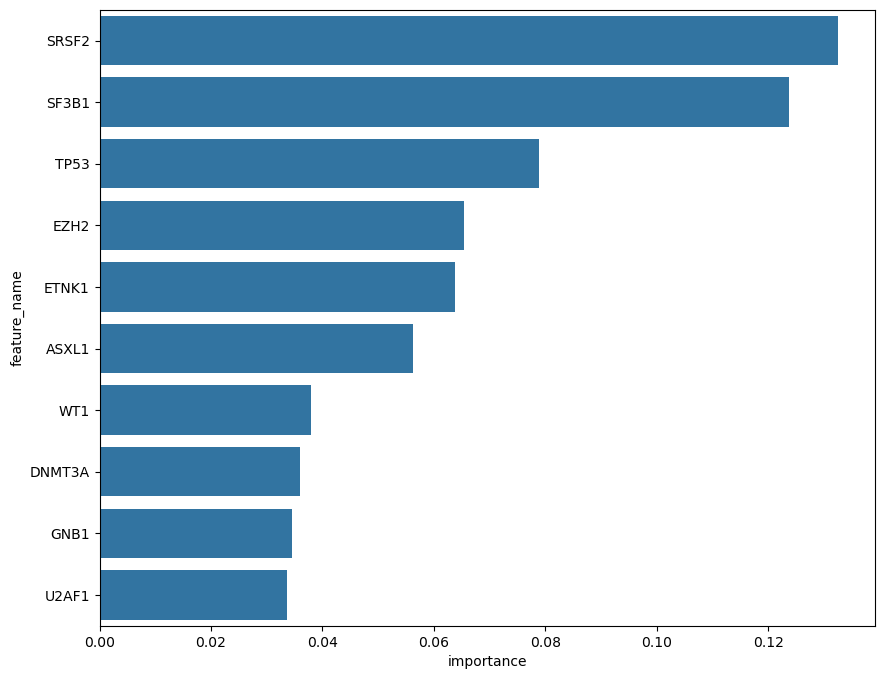

In [27]:
imp_df_muts = pd.DataFrame({'importance':mod.feature_importances_, 'feature_name' : mut_zdf.columns[3:]}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
sbn.barplot(data=imp_df_muts.head(10), y='feature_name', x='importance')
plt.show()

In [28]:
zdf[imp_df.feature_name.values[:3].tolist() + ['WBC']].corr(method='spearman')[['WBC']] 

,WBC
z5,0.021347
z30,-0.019950
z28,-0.119270
WBC,1.000000


In [29]:
zdf[imp_df.feature_name.values[:3].tolist() + ['Overall survival (days)']].corr(method='spearman')[['Overall survival (days)']] 


,Overall survival (days)
z5,-0.253883
z30,-0.014594
z28,-0.086711
Overall survival (days),1.000000
